# CliffWalking Random Baseline

## 实验目标

这个 notebook 不训练任何策略，也不使用强化学习算法。它的目标是先展示在 CliffWalking 环境里完全随机选择动作时，智能体通常会有多容易掉下悬崖，以及这种随机试错为什么几乎不可能形成稳定路径。这个 baseline 会作为后续 `Q-Learning` notebook 的参照系，用来帮助读者先建立一个最直观的环境难度印象。


## 环境背景

CliffWalking 是一个经典的网格世界风险控制任务。智能体需要从左下角起点移动到右下角终点，但这两点之间紧贴着一整段悬崖区域。只要一步踩进悬崖，就会立刻受到巨大惩罚并被重置回起点。

这个环境的教学价值很高，因为它同时包含两层难点：

- 需要找到一条能够到达终点的路径
- 需要在“更短但更危险”和“更稳但可能更绕”的路径之间做权衡

因此，它非常适合用来观察不同强化学习方法的风险偏好差异。


## 方法说明

这里的方法就是纯随机动作采样：每一步直接调用 `env.action_space.sample()` 选择动作，不维护价值函数，也不更新策略。它不是正式算法，但它能非常直观地说明这个环境为什么不能依赖随机行为解决。


## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

原因是这个 notebook 主要做的是环境交互统计，不涉及神经网络训练。


In [1]:
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


In [2]:
ENV_ID = "CliffWalking-v1"
NUM_EPISODES = 5000
MAX_STEPS = 200
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)


## 参数选择说明

- `NUM_EPISODES = 5000`：让随机策略的统计结果更稳定，避免只看到少量偶然回合
- `MAX_STEPS = 200`：给足够步数观察随机游走、掉崖和偶然到达终点的情况

这里的重点不是训练效率，而是建立一个清晰的风险基线。只要这个基线足够稳定，后续 `Q-Learning` 的提升才有解释力。


In [3]:
episode_rewards = []
episode_lengths = []
successes = []
cliff_falls = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    state, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    fell = 0

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if reward <= -100:
            fell = 1

        state = next_state

        if terminated or truncated:
            episode_lengths.append(step + 1)
            successes.append(int(terminated))
            break
    else:
        episode_lengths.append(MAX_STEPS)
        successes.append(0)

    episode_rewards.append(total_reward)
    cliff_falls.append(fell)

env.close()


Random episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame(
    {
        "reward": episode_rewards,
        "episode_length": episode_lengths,
        "success": successes,
        "cliff_fall": cliff_falls,
    }
)
summary.describe(include="all")


,reward,episode_length,success,cliff_fall
count,5000.0000,5000.00000,5000.000000,5000.000000
mean,-2066.5176,198.24900,0.023200,0.997600
std,671.7851,13.36564,0.150553,0.048936
min,-5447.0000,29.00000,0.000000,0.000000
25%,-2477.0000,200.00000,0.000000,1.000000
50%,-2081.0000,200.00000,0.000000,1.000000
75%,-1586.0000,200.00000,0.000000,1.000000
max,-29.0000,200.00000,1.000000,1.000000


In [5]:
success_rate = float(np.mean(successes))
avg_reward = float(np.mean(episode_rewards))
avg_length = float(np.mean(episode_lengths))
fall_rate = float(np.mean(cliff_falls))

metrics = pd.DataFrame(
    {
        "metric": ["success_rate", "average_reward", "average_episode_length", "cliff_fall_rate"],
        "value": [success_rate, avg_reward, avg_length, fall_rate],
    }
)
metrics


,metric,value
0,success_rate,0.0232
1,average_reward,-2066.5176
2,average_episode_length,198.2490
3,cliff_fall_rate,0.9976


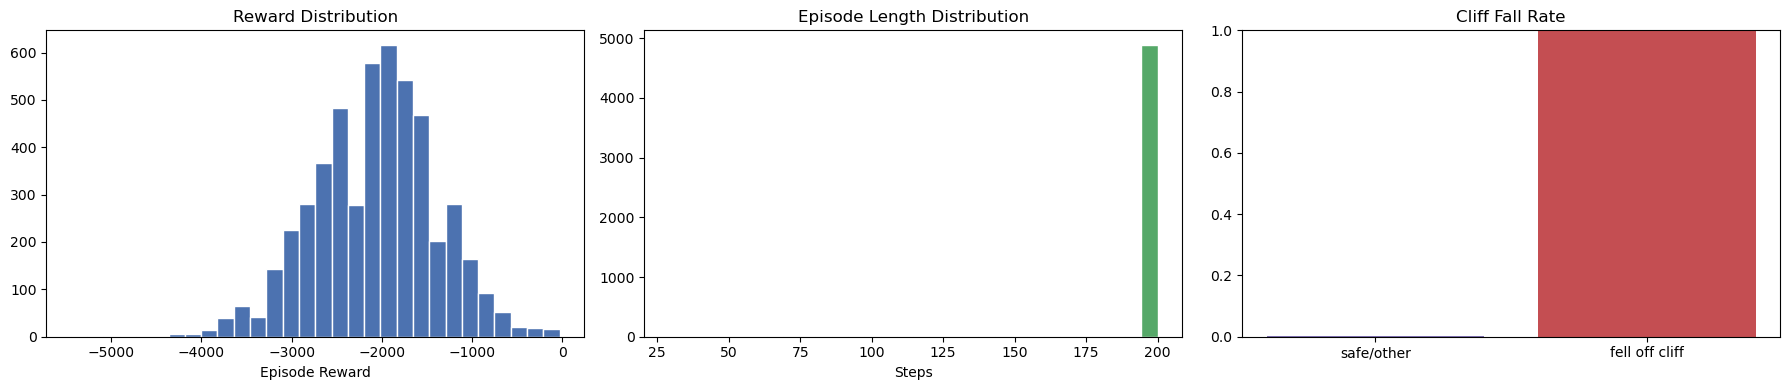

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(episode_rewards, bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Reward Distribution")
axes[0].set_xlabel("Episode Reward")

axes[1].hist(episode_lengths, bins=30, color="#55a868", edgecolor="white")
axes[1].set_title("Episode Length Distribution")
axes[1].set_xlabel("Steps")

axes[2].bar(["safe/other", "fell off cliff"], [1 - fall_rate, fall_rate], color=["#8172b3", "#c44e52"])
axes[2].set_title("Cliff Fall Rate")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)

print(f"Success rate: {success_rate:.4f}")
print(f"Average reward: {avg_reward:.2f}")
print(f"Average episode length: {avg_length:.2f}")
print(f"Cliff fall rate: {fall_rate:.4f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")


Success rate: 0.0232
Average reward: -2066.52
Average episode length: 198.25
Cliff fall rate: 0.9976
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/04-cliffwalking-q-learning/results


## 结果解读

随机策略在 CliffWalking 里通常会频繁掉下悬崖，平均回报很差，真正稳定到达终点的比例也会很低。这说明这个环境的核心挑战不是简单到达终点，而是在带有巨大风险惩罚的区域里学会更稳妥的路径选择。

这样在进入 `Q-Learning` 后，读者就能更直观地看到：策略提升并不是偶然碰运气，而是通过价值更新逐步形成的。
